<a href="https://colab.research.google.com/github/FabioOrtizO/AnalisisDatos/blob/main/Tarea2_Fabio_Ortiz_An%C3%A1lisis_Exploratorio_e_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Metodos Estadisticos en la Ciencia de Datos</p>

<p style="text-align: center;"> Código Curso: 203008072 </p>

<p style="text-align: center;"> Tarea  2 Análisis Exploratorio e Inferencial</p>

<p style="text-align: center;">  Presentado por: Fabio Ernesto Ortiz Otalora</p>

<p style="text-align: center;"> Código: 1118566776</p>

<p style="text-align: center;">  Tutor(a): Esneider de Jesus Pineda Martinez </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Septiembre2026</p>

# Importar librerias

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Importación dataset

In [61]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/Colab Notebooks/Anexo 1 - Base de Datos dynamic_pricing.csv"
df = pd.read_csv(path, encoding="latin1")

print(df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.26
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.87
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.80
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.20
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.68


# Exploración estructural del dataset

In [62]:
# Información general del dataset
print("Dimensiones del dataset (filas, columnas):", df.shape)
print("\nTipos de datos por columna:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas (variables numéricas):")
df.describe()

Dimensiones del dataset (filas, columnas): (1000, 10)

Tipos de datos por columna:
Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category           object
Customer_Loyalty_Status     object
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking             object
Vehicle_Type                object
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
dtype: object

Valores nulos por columna:
Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

Estadísticas descriptivas (variables numéricas):


,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,60.37,27.08,50.03,4.26,99.59,372.50
std,23.70,19.07,29.31,0.44,49.17,187.16
min,20.00,5.00,0.00,3.50,10.00,25.99
25%,40.00,11.00,25.00,3.87,59.75,221.37
50%,60.00,22.00,51.00,4.27,102.00,362.02
75%,81.00,38.00,75.00,4.63,143.00,510.50
max,100.00,89.00,100.00,5.00,180.00,836.12


# Frecuencias de variables categóricas

In [63]:
print("Distribución por nivel de fidelización (Customer_Loyalty_Status):")
print(df['Customer_Loyalty_Status'].value_counts())

print("\nDistribución por tipo de vehículo (Vehicle_Type):")
print(df['Vehicle_Type'].value_counts())

print("\nDistribución por categoría de ubicación (Location_Category):")
print(df['Location_Category'].value_counts())

Distribución por nivel de fidelización (Customer_Loyalty_Status):
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64

Distribución por tipo de vehículo (Vehicle_Type):
Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64

Distribución por categoría de ubicación (Location_Category):
Location_Category
Urban       346
Rural       332
Suburban    322
Name: count, dtype: int64


# Análisis descriptivo de las variables clave

In [64]:
variables_clave = ['Expected_Ride_Duration', 'Average_Ratings', 'Historical_Cost_of_Ride']

for var in variables_clave:
    print(f"\n--- {var} ---")
    print(f"Media: {df[var].mean():.2f}")
    print(f"Mediana: {df[var].median():.2f}")
    print(f"Desviación estándar: {df[var].std():.2f}")
    print(f"Mínimo: {df[var].min():.2f} | Máximo: {df[var].max():.2f}")


--- Expected_Ride_Duration ---
Media: 99.59
Mediana: 102.00
Desviación estándar: 49.17
Mínimo: 10.00 | Máximo: 180.00

--- Average_Ratings ---
Media: 4.26
Mediana: 4.27
Desviación estándar: 0.44
Mínimo: 3.50 | Máximo: 5.00

--- Historical_Cost_of_Ride ---
Media: 372.50
Mediana: 362.02
Desviación estándar: 187.16
Mínimo: 25.99 | Máximo: 836.12


# Visualización univariada (histogramas y boxplots)

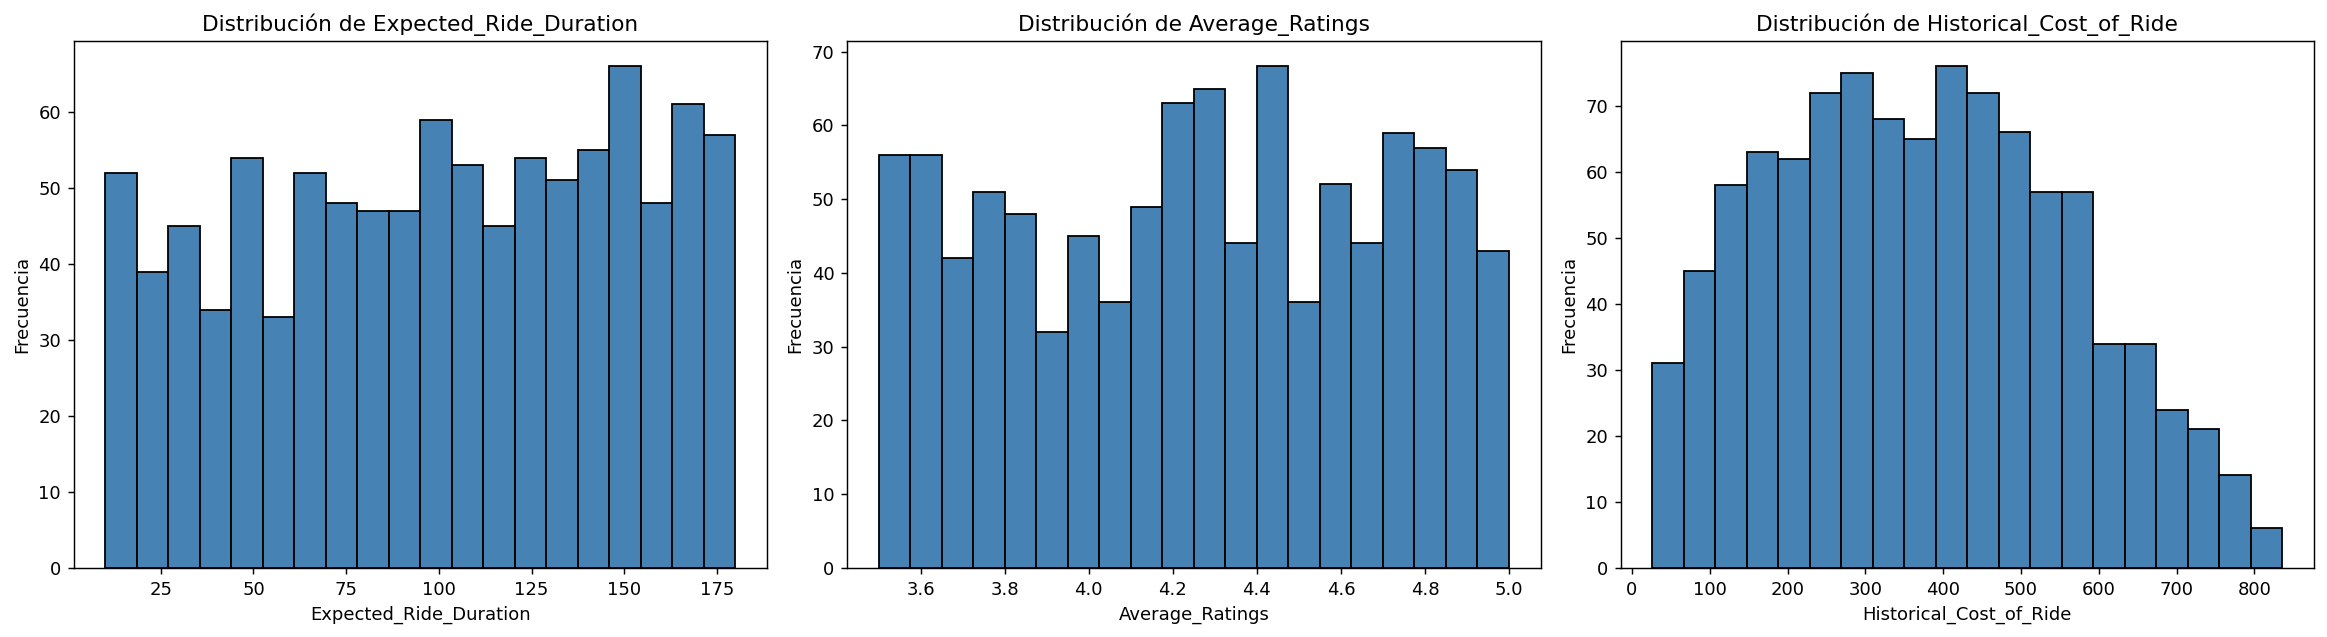

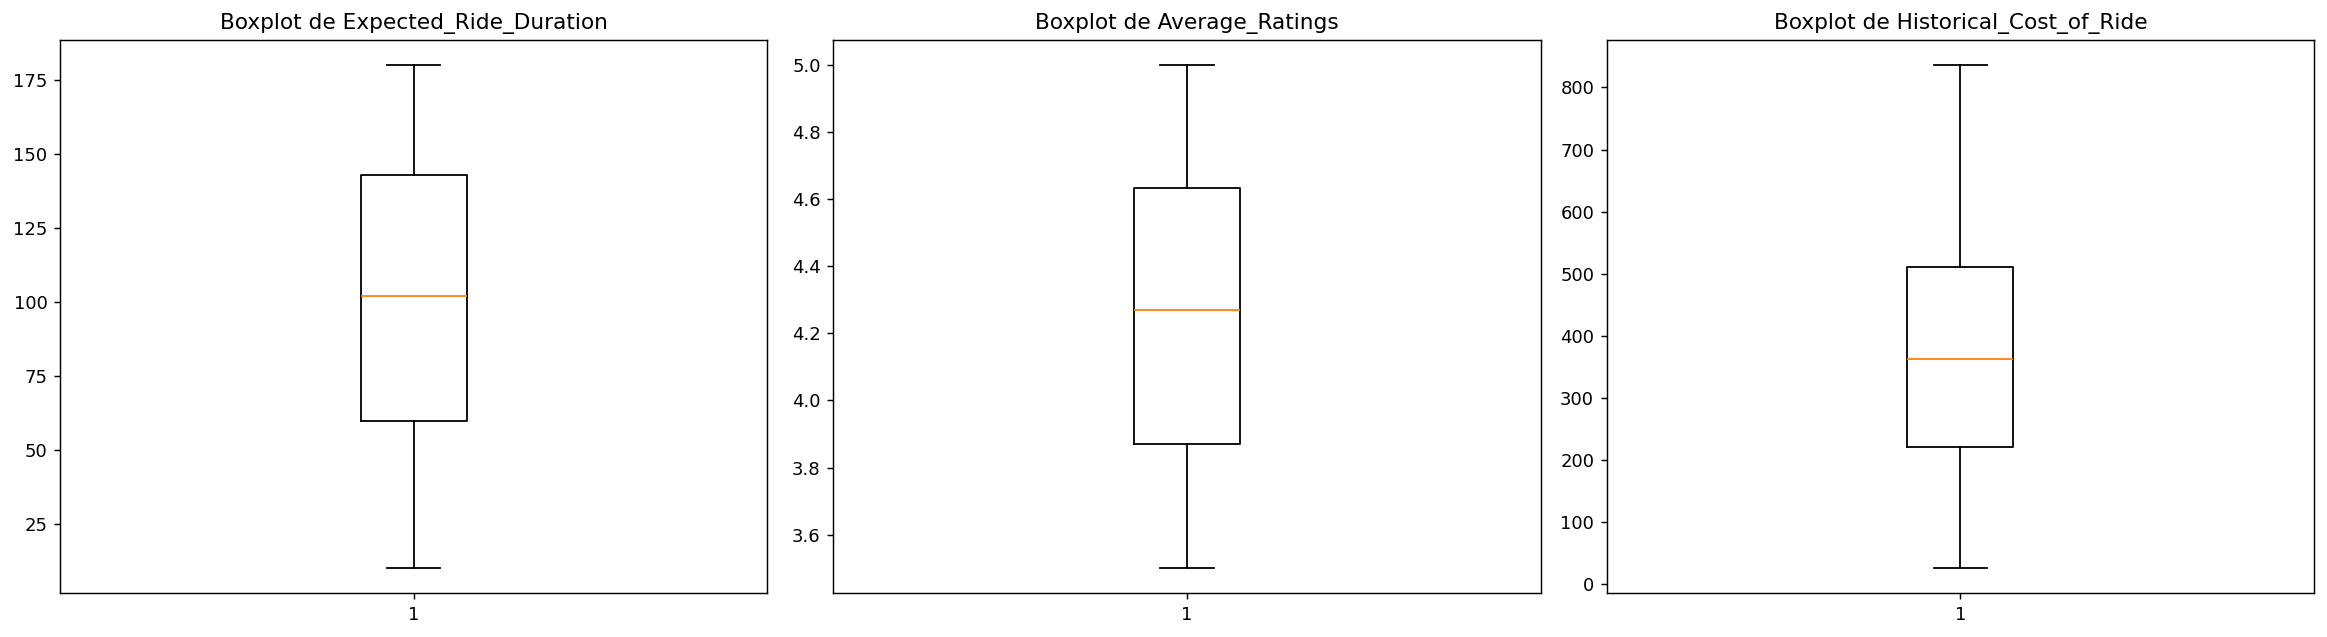

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(variables_clave):
    axes[i].hist(df[var], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(variables_clave):
    axes[i].boxplot(df[var], vert=True)
    axes[i].set_title(f'Boxplot de {var}')
plt.tight_layout()
plt.show()

## 2.1 Teorema Central del Límite (TCL) y su aplicación práctica

En esta sección se simulan múltiples muestras aleatorias de la variable `Expected_Ride_Duration` para observar el comportamiento de la distribución de las medias muestrales y verificar empíricamente el Teorema Central del Límite (TCL).

Distribución original de la variable

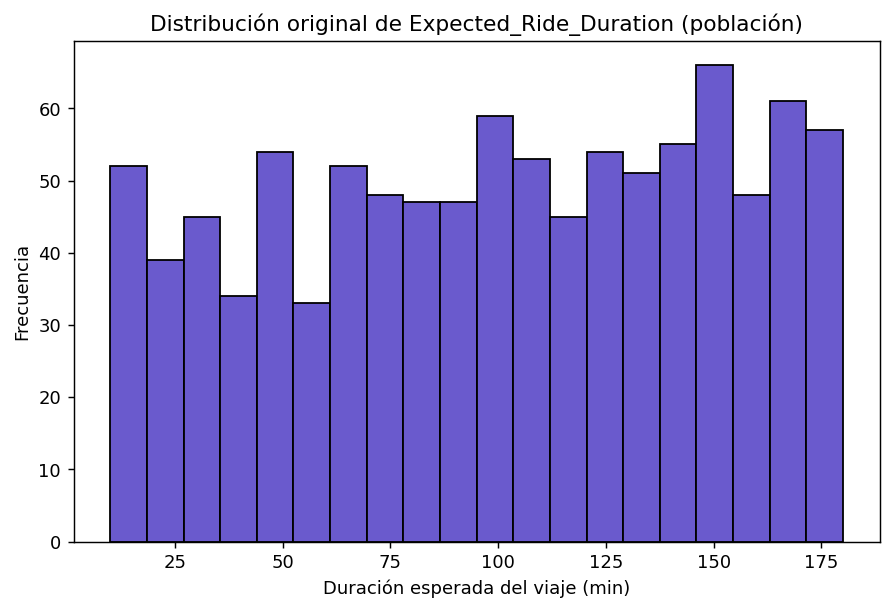

Asimetría (skewness): -0.14
Curtosis: -1.153


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Distribución original de la variable poblacional (antes de simular)
plt.figure(figsize=(8, 5))
plt.hist(df['Expected_Ride_Duration'], bins=20, color='slateblue', edgecolor='black')
plt.title('Distribución original de Expected_Ride_Duration (población)')
plt.xlabel('Duración esperada del viaje (min)')
plt.ylabel('Frecuencia')
plt.show()

print("Asimetría (skewness):", round(stats.skew(df['Expected_Ride_Duration']), 3))
print("Curtosis:", round(stats.kurtosis(df['Expected_Ride_Duration']), 3))

Simulación (n=30, 1000 repeticiones)

In [67]:
# 1. Fijamos semilla para reproducibilidad
np.random.seed(42)

# 2. Parámetros de la simulación
n_muestra = 30
n_repeticiones = 1000

# 3. Variable de interés
duracion = df['Expected_Ride_Duration'].values

# 4. Simulación: 1000 muestras aleatorias de tamaño 30, calculando la media de cada una
medias_muestrales = []
for _ in range(n_repeticiones):
    muestra = np.random.choice(duracion, size=n_muestra, replace=True)
    medias_muestrales.append(muestra.mean())

medias_muestrales = np.array(medias_muestrales)

# 5. Comparación de estadísticos: población vs. distribución muestral
print("== Población (Expected_Ride_Duration) ==")
print("Media poblacional:", round(duracion.mean(), 2))
print("Desviación estándar poblacional:", round(duracion.std(), 2))

print("\n== Distribución muestral de medias (n=30, 1000 repeticiones) ==")
print("Media de las medias muestrales:", round(medias_muestrales.mean(), 2))
print("Desviación estándar de las medias muestrales (error estándar empírico):",
      round(medias_muestrales.std(), 2))
print("Error estándar teórico (σ/√n):", round(duracion.std() / np.sqrt(n_muestra), 2))

== Población (Expected_Ride_Duration) ==
Media poblacional: 99.59
Desviación estándar poblacional: 49.14

== Distribución muestral de medias (n=30, 1000 repeticiones) ==
Media de las medias muestrales: 99.84
Desviación estándar de las medias muestrales (error estándar empírico): 9.11
Error estándar teórico (σ/√n): 8.97


Graficar la distribución de las medias muestrales

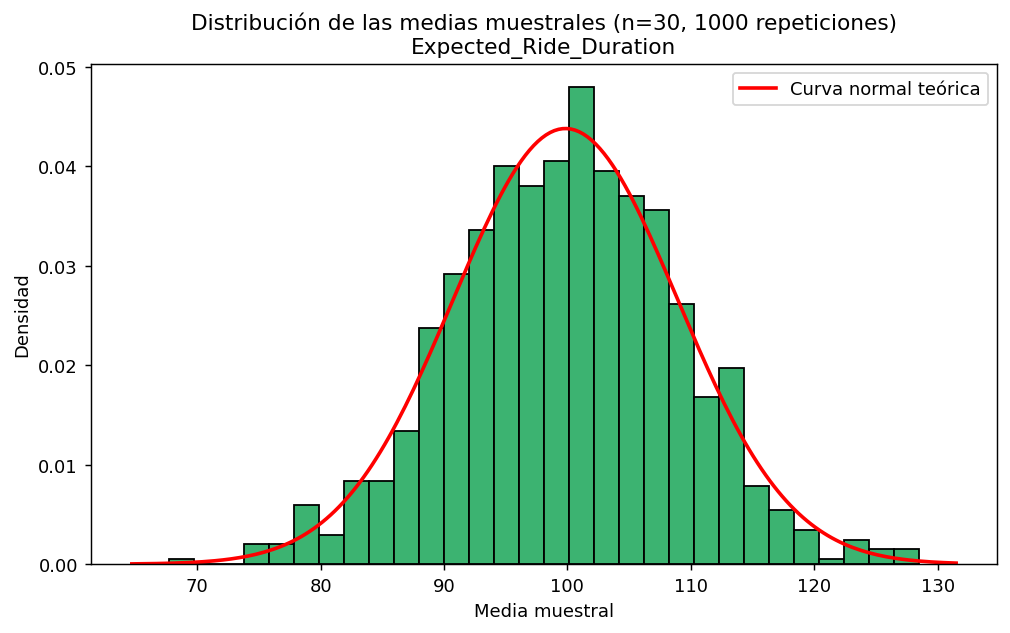

In [68]:
plt.figure(figsize=(9, 5))
plt.hist(medias_muestrales, bins=30, color='mediumseagreen', edgecolor='black', density=True)

# Superponer la curva normal teórica para comparación visual
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, medias_muestrales.mean(), medias_muestrales.std())
plt.plot(x, p, 'r-', linewidth=2, label='Curva normal teórica')

plt.title('Distribución de las medias muestrales (n=30, 1000 repeticiones)\nExpected_Ride_Duration')
plt.xlabel('Media muestral')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Verificación empírica de normalidad

Prueba de Shapiro-Wilk sobre las medias muestrales:
Estadístico = 0.9987 | p-valor = 0.6783
No se rechaza H0: la distribución de las medias muestrales es consistente con una normal (p > 0.05).

Asimetría de las medias muestrales: -0.021
Curtosis de las medias muestrales: 0.141


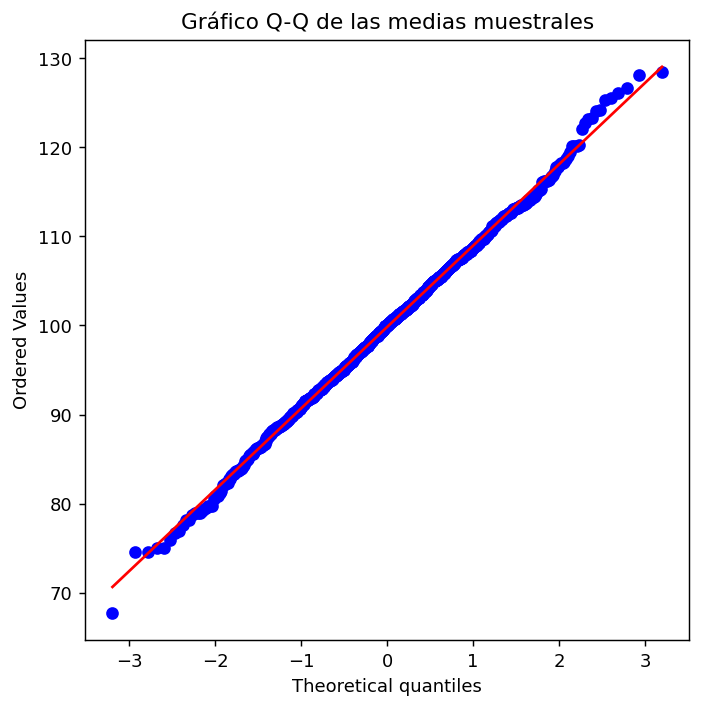

In [69]:
# Prueba de Shapiro-Wilk sobre las medias muestrales
shapiro_stat, shapiro_p = stats.shapiro(medias_muestrales)
print(f"Prueba de Shapiro-Wilk sobre las medias muestrales:")
print(f"Estadístico = {shapiro_stat:.4f} | p-valor = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("No se rechaza H0: la distribución de las medias muestrales es consistente con una normal (p > 0.05).")
else:
    print("Se rechaza H0: hay evidencia de desviación de la normalidad (p <= 0.05).")

# Asimetría y curtosis de las medias muestrales (para comparar con la población)
print("\nAsimetría de las medias muestrales:", round(stats.skew(medias_muestrales), 3))
print("Curtosis de las medias muestrales:", round(stats.kurtosis(medias_muestrales), 3))

# Gráfico Q-Q (cuantil-cuantil)
plt.figure(figsize=(6, 6))
stats.probplot(medias_muestrales, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de las medias muestrales')
plt.show()

### Interpretación de resultados

**Verificación empírica de la normalidad:**
La distribución original de `Expected_Ride_Duration` presenta un coeficiente de asimetría de -0.14 y una curtosis de -1.153. La asimetría cercana a cero indica que la variable original no presenta una asimetría marcada, pero la curtosis negativa señala una distribución platicúrtica (más "aplanada" que una normal, con colas más ligeras), lo cual es consistente con la forma observada en el histograma inicial: una distribución más uniforme que campaniforme, sin una clara concentración de datos alrededor de la media.

Al simular 1000 muestras aleatorias de tamaño n=30 de esta variable y calcular su media, la distribución resultante de esas medias muestrales cambia notablemente de forma y se aproxima a una distribución normal: el histograma muestra una forma simétrica y campaniforme, la curva normal teórica se ajusta bien a los datos simulados, y el gráfico Q-Q muestra que los puntos se alinean
estrechamente sobre la diagonal de referencia. Esto se refuerza con los  coeficientes de asimetría (-0.021) y curtosis (0.141) de las medias muestrales, ambos mucho más cercanos a cero que los de la variable original. La prueba de Shapiro-Wilk arrojó un estadístico de 0.9987 con un p-valor de 0.6783; dado que este p-valor es mayor al nivel de significancia α=0.05, **no se rechaza la
hipótesis nula de normalidad**, lo que indica que no existe evidencia estadística suficiente para afirmar que la distribución de las medias muestrales se aparta de la normalidad. Es importante precisar que este resultado no "confirma" ni "comprueba" la normalidad de forma absoluta, sino que
respalda dicha suposición en conjunto con la evidencia gráfica (histograma, curva normal superpuesta y gráfico Q-Q). Cabe señalar además que el criterio n≥30 usado en la simulación es una regla práctica comúnmente aceptada para la aplicación del TCL, y no una garantía automática de normalidad en todos los casos.

Análisis de sensibilidad del número de repeticiones

=== Análisis de sensibilidad: número de repeticiones en la simulación ===
 Repeticiones  Media de medias  SD de medias (error estándar)  p-valor Shapiro-Wilk
          500            99.92                           9.49                  0.15
         1000            99.72                           8.89                  0.72
         2000            99.65                           8.73                  0.98
         5000            99.74                           8.96                  0.94


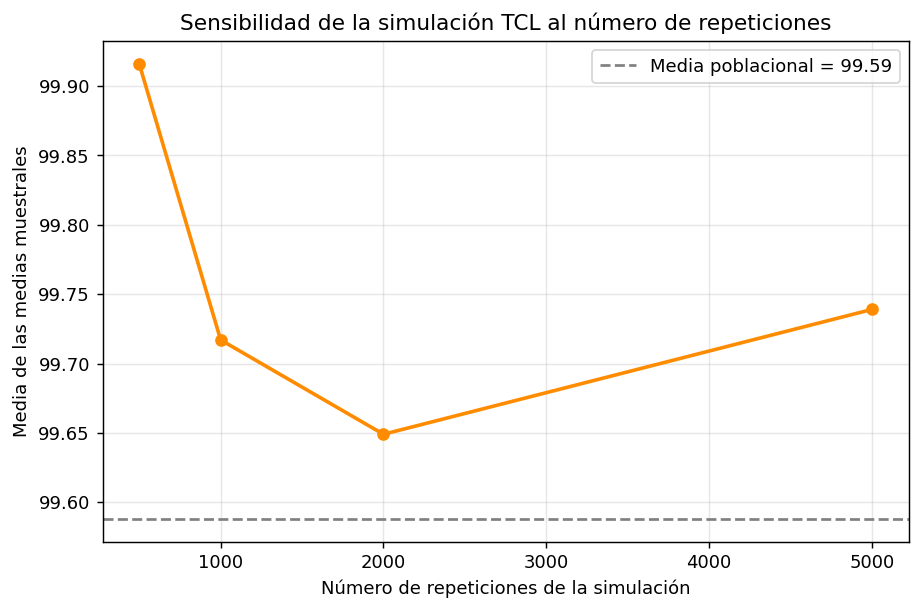

In [70]:
# Análisis de sensibilidad: ¿son suficientes 1000 repeticiones?
# Repetimos la simulación con distintos números de repeticiones y comparamos los resultados

np.random.seed(42)
n_muestra = 30
repeticiones_a_probar = [500, 1000, 2000, 5000]

resultados_sensibilidad = []

for reps in repeticiones_a_probar:
    medias_temp = []
    for _ in range(reps):
        muestra_temp = np.random.choice(duracion, size=n_muestra, replace=True)
        medias_temp.append(muestra_temp.mean())
    medias_temp = np.array(medias_temp)

    shapiro_stat_temp, shapiro_p_temp = stats.shapiro(medias_temp)

    resultados_sensibilidad.append({
        'Repeticiones': reps,
        'Media de medias': round(medias_temp.mean(), 3),
        'SD de medias (error estándar)': round(medias_temp.std(), 3),
        'p-valor Shapiro-Wilk': round(shapiro_p_temp, 4)
    })

tabla_sensibilidad = pd.DataFrame(resultados_sensibilidad)
print("=== Análisis de sensibilidad: número de repeticiones en la simulación ===")
print(tabla_sensibilidad.to_string(index=False))

# Visualización de la estabilidad de la media simulada según el número de repeticiones
plt.figure(figsize=(8, 5))
plt.plot(tabla_sensibilidad['Repeticiones'], tabla_sensibilidad['Media de medias'],
         marker='o', color='darkorange', linewidth=2)
plt.axhline(y=duracion.mean(), color='gray', linestyle='--',
            label=f'Media poblacional = {duracion.mean():.2f}')
plt.xlabel('Número de repeticiones de la simulación')
plt.ylabel('Media de las medias muestrales')
plt.title('Sensibilidad de la simulación TCL al número de repeticiones')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Análisis de sensibilidad del número de repeticiones:**
Para verificar si 1000 repeticiones fueron suficientes para obtener una simulación estable y confiable del Teorema Central del Límite, se repitió el experimento con distintos números de repeticiones (500, 1000, 2000 y 5000), manteniendo el tamaño de muestra en n=30.

| Repeticiones | Media de medias | SD de medias | p-valor Shapiro-Wilk |
|---|---|---|---|
| 500 | 99.916 | 9.491 | 0.1514 |
| 1000 | 99.717 | 8.895 | 0.7249 |
| 2000 | 99.649 | 8.731 | 0.9780 |
| 5000 | 99.739 | 8.958 | 0.9417 |

Como se observa, la media de las medias muestrales se mantiene consistentemente cercana a la media poblacional (99.59) en todos los escenarios, con variaciones mínimas incluso al aumentar considerablemente el número de repeticiones (de 500 a 5000). De igual forma, la prueba de Shapiro-Wilk no rechaza la normalidad en ningún caso (todos los p-valores superan ampliamente α=0.05). Esto indica que **1000 repeticiones resultaron suficientes** para obtener una aproximación estable y consistente del comportamiento de la distribución muestral, sin que un
mayor número de repeticiones aporte cambios sustanciales a las conclusiones del análisis. Esta verificación refuerza la robustez metodológica del ejercicio de simulación realizado en este informe.

## 2.2 Intervalos de Confianza (IC)

En esta sección se construyen intervalos de confianza del 95% para tres parámetros poblacionales distintos: la media de `Expected_Ride_Duration`, la proporción de calificaciones excelentes (`Average_Ratings` ≥ 4.0) y la varianza de `Historical_Cost_of_Ride`.

IC 95% para la media (Expected_Ride_Duration)

In [71]:
from scipy import stats

n = len(df)
x = df['Expected_Ride_Duration']

media = x.mean()
desv_est = x.std(ddof=1)          # desviación estándar muestral
error_estandar = desv_est / np.sqrt(n)

# Como n es grande (1000) pero no conocemos sigma poblacional, usamos t de Student
t_critico = stats.t.ppf(0.975, df=n-1)   # 95% de confianza, dos colas

ic_inf_media = media - t_critico * error_estandar
ic_sup_media = media + t_critico * error_estandar

print("=== IC 95% para la media de Expected_Ride_Duration ===")
print(f"Media muestral: {media:.2f}")
print(f"Desviación estándar muestral: {desv_est:.2f}")
print(f"Error estándar: {error_estandar:.4f}")
print(f"Valor crítico t (gl={n-1}): {t_critico:.4f}")
print(f"Intervalo de confianza 95%: ({ic_inf_media:.2f}, {ic_sup_media:.2f})")

=== IC 95% para la media de Expected_Ride_Duration ===
Media muestral: 99.59
Desviación estándar muestral: 49.17
Error estándar: 1.5547
Valor crítico t (gl=999): 1.9623
Intervalo de confianza 95%: (96.54, 102.64)


IC 95% para la proporción (Average_Ratings ≥ 4.0)

In [72]:
# Definimos la variable binaria: 1 si la calificación es "excelente" (>=4.0), 0 si no
excelente = (df['Average_Ratings'] >= 4.0).astype(int)

p_muestral = excelente.mean()
error_estandar_p = np.sqrt(p_muestral * (1 - p_muestral) / n)
z_critico = stats.norm.ppf(0.975)   # 95% de confianza, dos colas

ic_inf_p = p_muestral - z_critico * error_estandar_p
ic_sup_p = p_muestral + z_critico * error_estandar_p

print("=== IC 95% para la proporción de Average_Ratings >= 4.0 ===")
print(f"Número de viajes con calificación excelente: {excelente.sum()} de {n}")
print(f"Proporción muestral: {p_muestral:.4f} ({p_muestral*100:.2f}%)")
print(f"Error estándar: {error_estandar_p:.4f}")
print(f"Valor crítico z: {z_critico:.4f}")
print(f"Intervalo de confianza 95%: ({ic_inf_p:.4f}, {ic_sup_p:.4f})")
print(f"En porcentaje: ({ic_inf_p*100:.2f}%, {ic_sup_p*100:.2f}%)")

=== IC 95% para la proporción de Average_Ratings >= 4.0 ===
Número de viajes con calificación excelente: 686 de 1000
Proporción muestral: 0.6860 (68.60%)
Error estándar: 0.0147
Valor crítico z: 1.9600
Intervalo de confianza 95%: (0.6572, 0.7148)
En porcentaje: (65.72%, 71.48%)


IC 95% para la varianza (Historical_Cost_of_Ride)

In [73]:
y = df['Historical_Cost_of_Ride']
varianza_muestral = y.var(ddof=1)
gl = n - 1

# Valores críticos de la distribución chi-cuadrado (dos colas)
chi2_inferior = stats.chi2.ppf(0.025, df=gl)   # cola izquierda (usada para el límite superior del IC)
chi2_superior = stats.chi2.ppf(0.975, df=gl)   # cola derecha (usada para el límite inferior del IC)

ic_inf_var = (gl * varianza_muestral) / chi2_superior
ic_sup_var = (gl * varianza_muestral) / chi2_inferior

print("=== IC 95% para la varianza de Historical_Cost_of_Ride ===")
print(f"Varianza muestral: {varianza_muestral:.2f}")
print(f"Desviación estándar muestral: {np.sqrt(varianza_muestral):.2f}")
print(f"Grados de libertad: {gl}")
print(f"Chi-cuadrado inferior (0.025): {chi2_inferior:.2f}")
print(f"Chi-cuadrado superior (0.975): {chi2_superior:.2f}")
print(f"Intervalo de confianza 95% para la varianza: ({ic_inf_var:.2f}, {ic_sup_var:.2f})")
print(f"Intervalo de confianza 95% para la desviación estándar: ({np.sqrt(ic_inf_var):.2f}, {np.sqrt(ic_sup_var):.2f})")

=== IC 95% para la varianza de Historical_Cost_of_Ride ===
Varianza muestral: 35028.40
Desviación estándar muestral: 187.16
Grados de libertad: 999
Chi-cuadrado inferior (0.025): 913.30
Chi-cuadrado superior (0.975): 1088.49
Intervalo de confianza 95% para la varianza: (32148.63, 38315.27)
Intervalo de confianza 95% para la desviación estándar: (179.30, 195.74)


Visualización de los tres IC

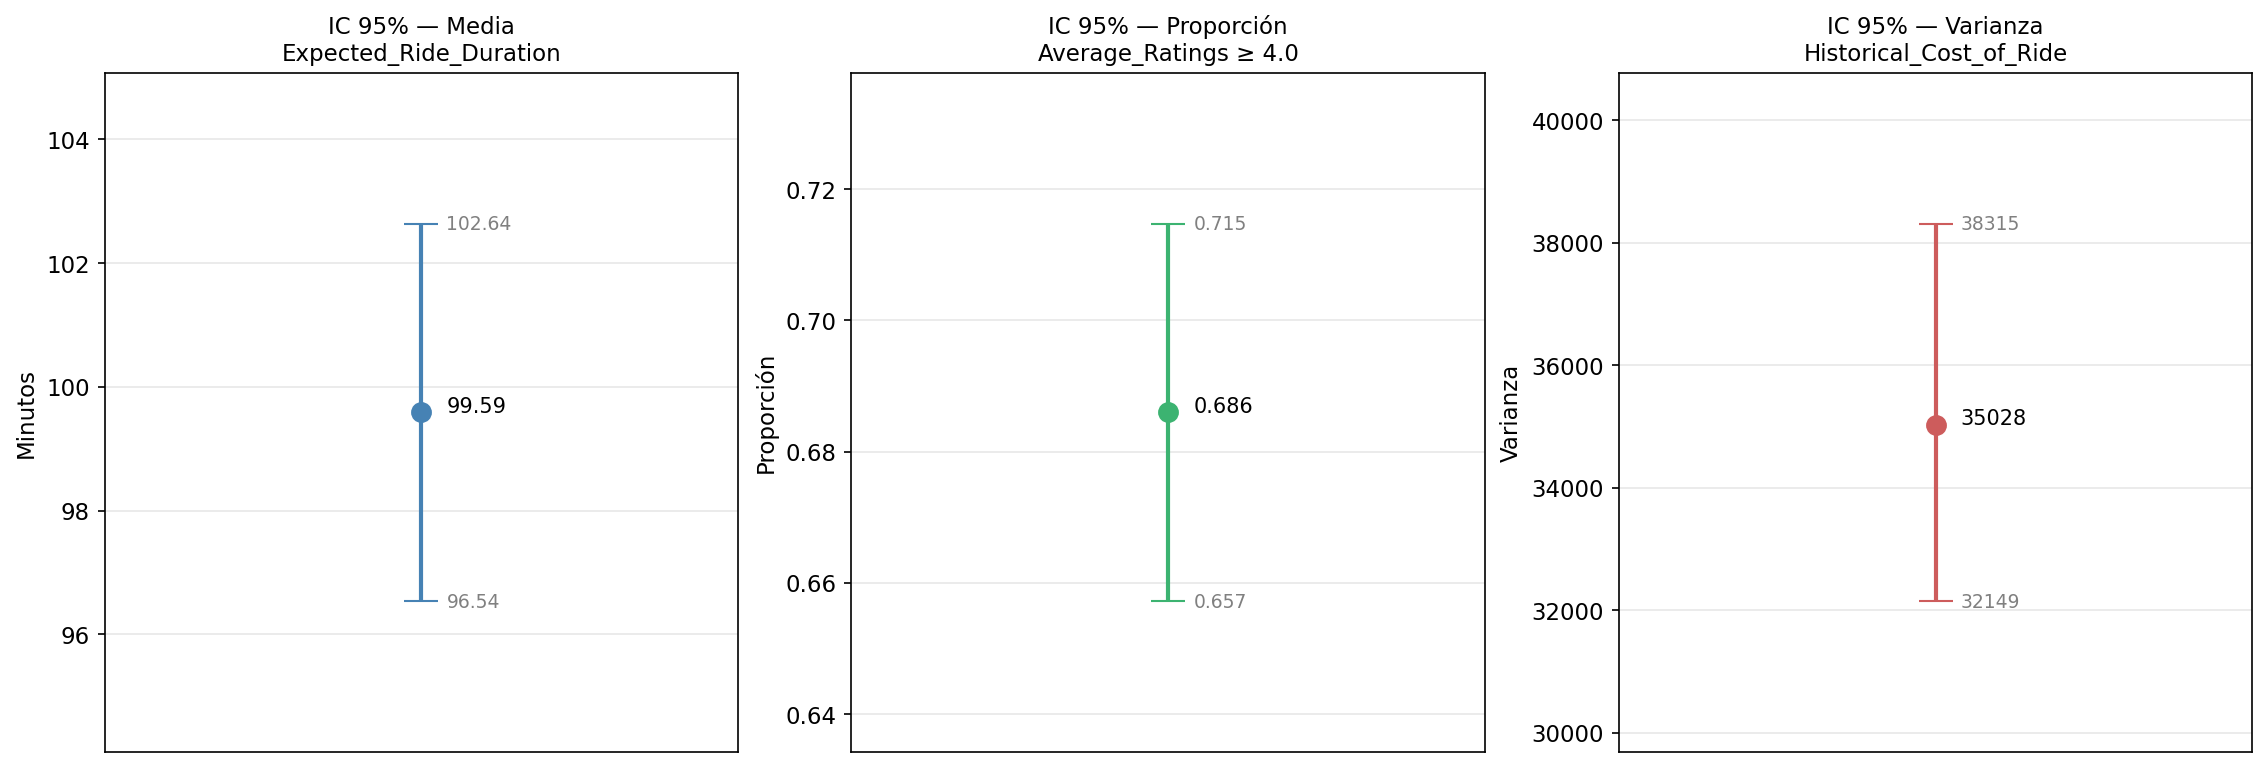

In [74]:
# Configuración global para que los gráficos se vean bien al exportar a PDF
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# --- IC media ---
ax = axes[0]
ax.errorbar(x=[1], y=[media], yerr=[[media - ic_inf_media], [ic_sup_media - media]],
            fmt='o', color='steelblue', capsize=8, markersize=9, elinewidth=2)
margen = (ic_sup_media - ic_inf_media) * 0.4
ax.set_ylim(ic_inf_media - margen, ic_sup_media + margen)
ax.set_xlim(0.5, 1.5)
ax.set_xticks([])
ax.set_title('IC 95% — Media\nExpected_Ride_Duration', fontsize=11)
ax.set_ylabel('Minutos')
ax.annotate(f'{media:.2f}', (1, media), textcoords="offset points", xytext=(12, 0), fontsize=10)
ax.annotate(f'{ic_inf_media:.2f}', (1, ic_inf_media), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.annotate(f'{ic_sup_media:.2f}', (1, ic_sup_media), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

# --- IC proporción ---
ax = axes[1]
ax.errorbar(x=[1], y=[p_muestral], yerr=[[p_muestral - ic_inf_p], [ic_sup_p - p_muestral]],
            fmt='o', color='mediumseagreen', capsize=8, markersize=9, elinewidth=2)
margen = (ic_sup_p - ic_inf_p) * 0.4
ax.set_ylim(ic_inf_p - margen, ic_sup_p + margen)
ax.set_xlim(0.5, 1.5)
ax.set_xticks([])
ax.set_title('IC 95% — Proporción\nAverage_Ratings ≥ 4.0', fontsize=11)
ax.set_ylabel('Proporción')
ax.annotate(f'{p_muestral:.3f}', (1, p_muestral), textcoords="offset points", xytext=(12, 0), fontsize=10)
ax.annotate(f'{ic_inf_p:.3f}', (1, ic_inf_p), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.annotate(f'{ic_sup_p:.3f}', (1, ic_sup_p), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

# --- IC varianza ---
ax = axes[2]
ax.errorbar(x=[1], y=[varianza_muestral], yerr=[[varianza_muestral - ic_inf_var], [ic_sup_var - varianza_muestral]],
            fmt='o', color='indianred', capsize=8, markersize=9, elinewidth=2)
margen = (ic_sup_var - ic_inf_var) * 0.4
ax.set_ylim(ic_inf_var - margen, ic_sup_var + margen)
ax.set_xlim(0.5, 1.5)
ax.set_xticks([])
ax.set_title('IC 95% — Varianza\nHistorical_Cost_of_Ride', fontsize=11)
ax.set_ylabel('Varianza')
ax.annotate(f'{varianza_muestral:.0f}', (1, varianza_muestral), textcoords="offset points", xytext=(12, 0), fontsize=10)
ax.annotate(f'{ic_inf_var:.0f}', (1, ic_inf_var), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.annotate(f'{ic_sup_var:.0f}', (1, ic_sup_var), textcoords="offset points", xytext=(12, -3), fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

plt.show()

### Interpretación de resultados

**IC 95% para la media de Expected_Ride_Duration: (96.54, 102.64) minutos**
Con un 95% de confianza, se estima que la duración esperada promedio real de los viajes en la población se encuentra entre 96.54 y 102.64 minutos. Este intervalo, relativamente estrecho (amplitud ≈ 6.1 minutos) gracias al tamaño de muestra grande (n=1000), le permite a la empresa planificar con precisión la asignación de tiempos de servicio y establecer expectativas realistas de duración de viaje frente a los usuarios, sin depender únicamente del  promedio puntual observado en la muestra.

**IC 95% para la proporción de Average_Ratings ≥ 4.0: (65.72%, 71.48%)**
Con un 95% de confianza, se estima que la verdadera proporción de viajes calificados como "excelentes" (calificación ≥ 4.0) en la población se ubica entre 65.72% y 71.48%. Este resultado es útil para la toma de decisiones porque permite establecer una línea base confiable de satisfacción del cliente: si en periodos futuros la proporción observada cae por debajo del límite inferior de este intervalo, sería una señal de alerta sobre un posible deterioro en la calidad del servicio que ameritaría investigación e intervención.

**IC 95% para la varianza de Historical_Cost_of_Ride: (32,148.63, 38,315.27)**
Con un 95% de confianza, se estima que la varianza poblacional del costo histórico de los viajes se encuentra entre 32,148.63 y 38,315.27 (unidades monetarias al cuadrado), lo que equivale a una desviación estándar poblacional entre aproximadamente 179.30 y 195.74 unidades monetarias. Esta alta variabilidad indica que el costo de los viajes no es homogéneo, lo cual es coherente con un esquema de precios dinámicos: conocer el rango de esta dispersión es útil para la empresa a la hora de fijar rangos de tarifas, evaluar la volatilidad de los ingresos por viaje y diseñar estrategias de precios diferenciadas según el segmento de clientes o el tipo de servicio.

**Utilidad conjunta para la toma de decisiones:**
Estos tres intervalos, en conjunto, le permiten a la organización tomar decisiones basadas en rangos de confianza estadísticamente respaldados en lugar de valores puntuales aislados: el IC de la media orienta la planeación operativa (tiempos de servicio), el IC de la proporción sirve como indicador de calidad para monitoreo continuo, y el IC de la varianza informa sobre la volatilidad financiera del negocio, insumo clave para la gestión de riesgo en el esquema de precios dinámicos.

## 2.3 Pruebas de Hipótesis para Comparación de Grupos

En esta sección se comparan dos grupos en dos variables distintas: la duración esperada del viaje (`Expected_Ride_Duration`) entre clientes Regular y Gold mediante una prueba t, y la proporción de calificaciones excelentes (`Average_Ratings` ≥ 4.0) entre tipos de vehículo (Economy vs. Premium) mediante una prueba de diferencia de proporciones.

Prueba t: Expected_Ride_Duration (Regular vs. Gold)

Grupo Regular: n = 320, media = 100.57, sd = 49.34
Grupo Gold:    n = 313, media = 101.60, sd = 50.17

Prueba de Levene (homogeneidad de varianzas): estadístico = 0.0144, p-valor = 0.9044

=== Prueba t: Expected_Ride_Duration (Regular vs. Gold) ===
Diferencia de medias (Regular - Gold): -1.0382
Estadístico t: -0.2625
Grados de libertad: 631
p-valor (dos colas): 0.7930

Decisión: No se rechaza H0 (p-valor 0.7930 >= α = 0.05)


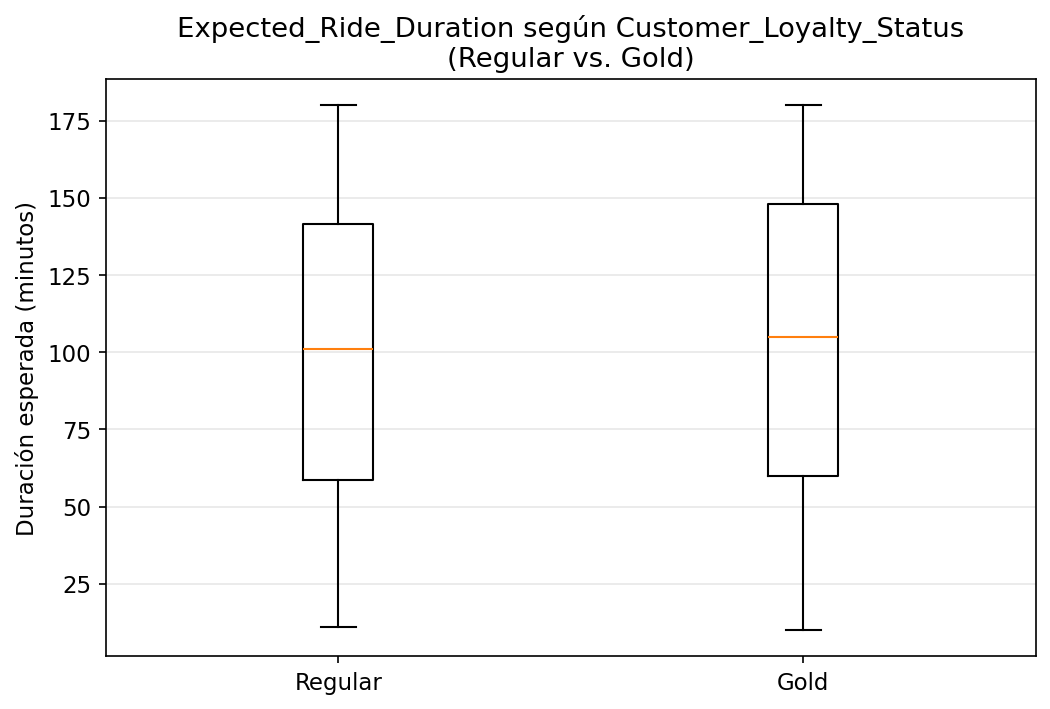

In [75]:
from scipy import stats

# 1. Separar los dos grupos de interés
regular = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']
gold = df[df['Customer_Loyalty_Status'] == 'Gold']['Expected_Ride_Duration']

print(f"Grupo Regular: n = {len(regular)}, media = {regular.mean():.2f}, sd = {regular.std(ddof=1):.2f}")
print(f"Grupo Gold:    n = {len(gold)}, media = {gold.mean():.2f}, sd = {gold.std(ddof=1):.2f}")

# 2. Verificar el supuesto de homogeneidad de varianzas (prueba de Levene)
levene_stat, levene_p = stats.levene(regular, gold)
print(f"\nPrueba de Levene (homogeneidad de varianzas): estadístico = {levene_stat:.4f}, p-valor = {levene_p:.4f}")

# 3. Prueba t para muestras independientes
# Como Levene no rechaza homogeneidad de varianzas (p > 0.05), usamos varianzas iguales
t_stat, p_valor = stats.ttest_ind(regular, gold, equal_var=True)
gl = len(regular) + len(gold) - 2

print(f"\n=== Prueba t: Expected_Ride_Duration (Regular vs. Gold) ===")
print(f"Diferencia de medias (Regular - Gold): {regular.mean() - gold.mean():.4f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor (dos colas): {p_valor:.4f}")

alpha = 0.05
if p_valor < alpha:
    print(f"\nDecisión: Se rechaza H0 (p-valor {p_valor:.4f} < α = {alpha})")
else:
    print(f"\nDecisión: No se rechaza H0 (p-valor {p_valor:.4f} >= α = {alpha})")

# 4. Visualización comparativa
plt.figure(figsize=(8, 5))
plt.boxplot([regular, gold], tick_labels=['Regular', 'Gold'])
plt.title('Expected_Ride_Duration según Customer_Loyalty_Status\n(Regular vs. Gold)')
plt.ylabel('Duración esperada (minutos)')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Hipótesis:**
H0: μ_Regular = μ_Gold (la duración esperada promedio del viaje es igual entre clientes Regular y Gold) - H1: μ_Regular ≠ μ_Gold (la duración esperada promedio del viaje difiere entre clientes Regular y Gold)

**Resultado y decisión:**
La prueba de Levene (p = 0.9044) confirma que las varianzas entre ambos grupos son homogéneas, por lo que se utilizó la prueba t de Student para varianzas iguales. Se obtuvo un estadístico t = -0.2625 con 631 grados de libertad y un p-valor de 0.7930. Dado que el p-valor (0.7930) es mucho mayor que el nivel de significancia α = 0.05, **no se rechaza H0**.

**Conclusión:**
No existe evidencia estadística suficiente para afirmar que la duración esperada promedio del viaje difiere entre clientes Regular (100.57 min) y clientes Gold (101.60 min). La pequeña diferencia observada (-1.04 minutos) es atribuible a la variabilidad muestral y no a una diferencia real en la población. Esto sugiere que el nivel de fidelización del cliente no está asociado con la duración esperada de sus viajes, lo cual sería relevante para la empresa si se busca segmentar estrategias operativas por tipo de cliente: en este aspecto particular, no habría justificación estadística para tratarlos de forma diferenciada.

Prueba de diferencia de proporciones: Average_Ratings ≥ 4.0 (Economy vs. premium)

In [76]:
economy = df[df['Vehicle_Type'] == 'Economy']
premium = df[df['Vehicle_Type'] == 'Premium']

x1, n1 = (economy['Average_Ratings'] >= 4.0).sum(), len(economy)
x2, n2 = (premium['Average_Ratings'] >= 4.0).sum(), len(premium)
p1, p2 = x1 / n1, x2 / n2

p_pool = (x1 + x2) / (n1 + n2)
error_estandar = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z_stat = (p1 - p2) / error_estandar
p_valor_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))
alpha = 0.05
decision = "Se rechaza H0" if p_valor_prop < alpha else "No se rechaza H0"

print(f"Economy: {x1}/{n1} (p={p1:.4f}) | Premium: {x2}/{n2} (p={p2:.4f})")
print(f"z = {z_stat:.4f} | p-valor = {p_valor_prop:.4f} | Decisión (α=0.05): {decision}")

Economy: 333/478 (p=0.6967) | Premium: 353/522 (p=0.6762)
z = 0.6946 | p-valor = 0.4873 | Decisión (α=0.05): No se rechaza H0


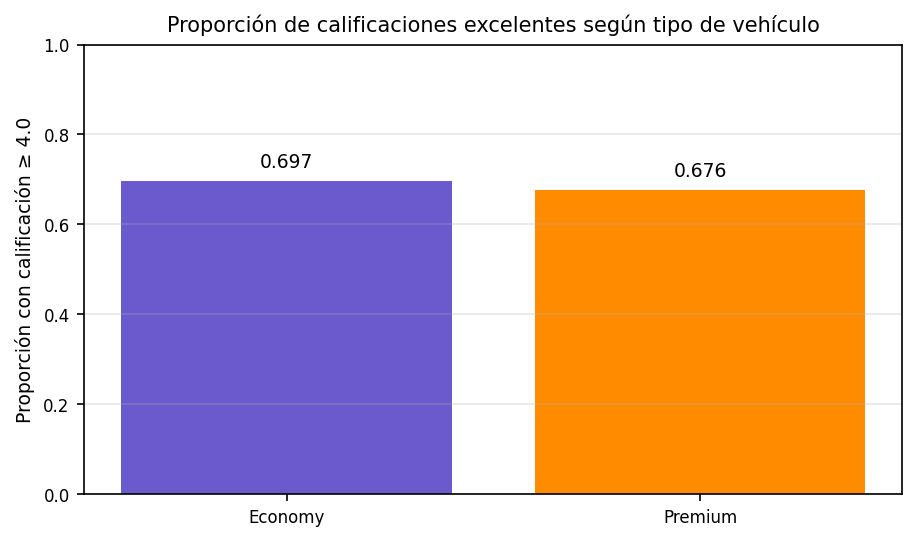

In [77]:
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ax.bar(['Economy', 'Premium'], [p1, p2], color=['slateblue', 'darkorange'])
ax.set_ylabel('Proporción con calificación ≥ 4.0', fontsize=9)
ax.set_title('Proporción de calificaciones excelentes según tipo de vehículo', fontsize=10)
ax.set_ylim(0, 1)
for i, val in enumerate([p1, p2]):
    ax.text(i, val + 0.03, f'{val:.3f}', ha='center', fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(axis='y', alpha=0.3)
plt.show()

**Hipótesis:**
H0: p_Economy = p_Premium (la proporción de calificaciones excelentes es igual entre Economy y Premium)
H1: p_Economy ≠ p_Premium (la proporción de calificaciones excelentes difiere entre Economy y Premium)

**Resultado y decisión:**
Se obtuvo una proporción de calificaciones excelentes de 69.67% en Economy (333 de 478 viajes) y de 67.62% en Premium (353 de 522 viajes). Con un estadístico z = 0.6946 y un p-valor de 0.4873, al ser este p-valor mayor que α = 0.05, **no se rechaza H0**.

**Conclusión:**
No existe evidencia estadística suficiente para afirmar que la proporción de viajes con calificación excelente (≥4.0) difiera entre los vehículos tipo Economy y Premium. La diferencia observada (2.04 puntos porcentuales) es pequeña y consistente con variabilidad muestral. Esto indica que el tipo de vehículo utilizado no está asociado con una mejor o peor percepción de
calidad por parte del cliente, un hallazgo relevante para la empresa: invertir en vehículos Premium no necesariamente se traduce en mejores calificaciones de servicio, por lo que otros factores (tiempo de espera, comportamiento del conductor, etc.) podrían tener mayor peso en la satisfacción del cliente.

## 2.4 Pruebas de Varianza (F de Fisher)

En esta sección se evalúa si la varianza de `Expected_Ride_Duration` difiere significativamente entre dos grupos de `Customer_Loyalty_Status` (Regular vs. Gold), utilizando la prueba F de Fisher.

**Justificación de la prueba F y sus supuestos:**
La prueba F de Fisher se utiliza para comparar las varianzas de dos poblaciones independientes, a partir del cociente entre sus varianzas muestrales. Es la prueba estadísticamente apropiada cuando el objetivo es evaluar la homogeneidad de varianzas entre dos grupos (por ejemplo, como paso previo para decidir si una prueba t debe aplicarse asumiendo varianzas iguales o distintas).
Sus supuestos son: (1) las dos muestras son independientes entre sí, (2) ambas poblaciones de origen siguen (aproximadamente) una distribución normal, y (3) los datos están medidos en escala de razón o intervalo. El supuesto de normalidad es razonable en este caso dado el tamaño de muestra de cada grupo (n > 300), que por el Teorema Central del Límite favorece la aproximación a la normalidad de los estadísticos derivados, aunque la prueba F es sensible a desviaciones de normalidad, por lo que sus resultados deben interpretarse con cautela.

Prueba F de Fisher

In [78]:
from scipy import stats

regular = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']
gold = df[df['Customer_Loyalty_Status'] == 'Gold']['Expected_Ride_Duration']

var_regular, var_gold = regular.var(ddof=1), gold.var(ddof=1)
n_regular, n_gold = len(regular), len(gold)

if var_regular > var_gold:
    F_stat = var_regular / var_gold
    df1, df2 = n_regular - 1, n_gold - 1
    orden = "Regular / Gold"
else:
    F_stat = var_gold / var_regular
    df1, df2 = n_gold - 1, n_regular - 1
    orden = "Gold / Regular"

p_valor_F = 2 * min(stats.f.cdf(F_stat, df1, df2), 1 - stats.f.cdf(F_stat, df1, df2))
alpha = 0.05
decision = "Se rechaza H0" if p_valor_F < alpha else "No se rechaza H0"

print(f"Regular: n={n_regular}, var={var_regular:.2f}, sd={np.sqrt(var_regular):.2f} | Gold: n={n_gold}, var={var_gold:.2f}, sd={np.sqrt(var_gold):.2f}")
print(f"F ({orden}) = {F_stat:.4f} | df1={df1}, df2={df2} | p-valor = {p_valor_F:.4f} | Decisión (α=0.05): {decision}")

Regular: n=320, var=2434.85, sd=49.34 | Gold: n=313, var=2516.82, sd=50.17
F (Gold / Regular) = 1.0337 | df1=312, df2=319 | p-valor = 0.7686 | Decisión (α=0.05): No se rechaza H0


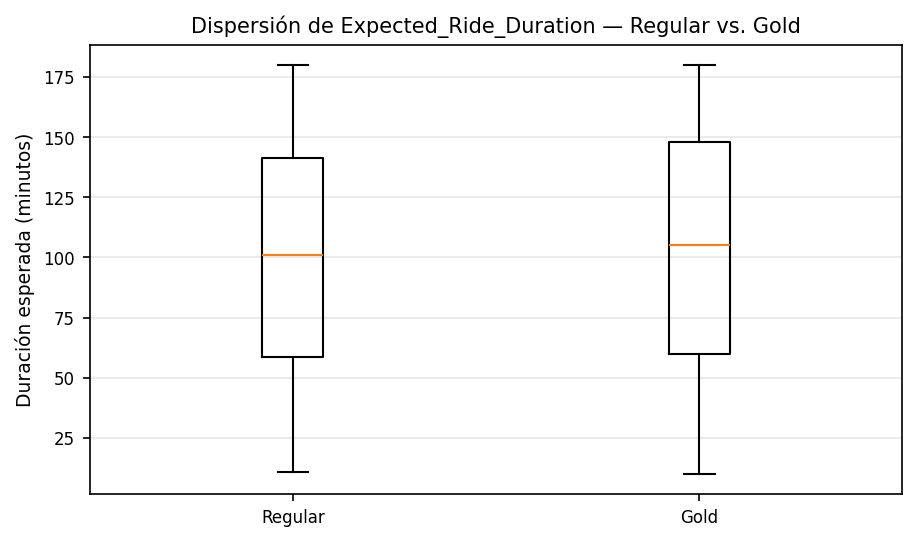

In [79]:
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ax.boxplot([regular, gold], tick_labels=['Regular', 'Gold'])
ax.set_title('Dispersión de Expected_Ride_Duration — Regular vs. Gold', fontsize=10)
ax.set_ylabel('Duración esperada (minutos)', fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(axis='y', alpha=0.3)
plt.show()

**Hipótesis:**
H0: σ²_Regular = σ²_Gold (las varianzas de la duración esperada del viaje son iguales entre clientes Regular y Gold)
H1: σ²_Regular ≠ σ²_Gold (las varianzas de la duración esperada del viaje difieren entre clientes Regular y Gold)

**Resultado y decisión:**
La varianza de `Expected_Ride_Duration` fue de 2,434.85 en el grupo Regular (sd = 49.34) y de
2,516.82 en el grupo Gold (sd = 50.17). El cociente de varianzas arrojó un estadístico F = 1.0337
con df1 = 312 y df2 = 319 grados de libertad, y un p-valor de 0.7686. Dado que este p-valor es
mayor al nivel de significancia α = 0.05, **no se rechaza H0**.

**Conclusión:**
No se encontró evidencia estadística suficiente para afirmar que las varianzas de la duración
esperada del viaje difieran entre los clientes Regular y Gold. La pequeña diferencia observada
entre ambas varianzas es atribuible a la variabilidad propia del muestreo y no a una diferencia
real en la población. Este resultado es consistente con la homogeneidad de varianzas ya verificada
mediante la prueba de Levene en el paso 2.3, y refuerza la validez de haber aplicado la prueba t
de Student asumiendo varianzas iguales en dicho análisis. Desde la perspectiva del negocio, esto
sugiere que la variabilidad en los tiempos de viaje no está asociada con el nivel de fidelización
del cliente, es decir, ambos segmentos experimentan una dispersión similar en la duración de sus
viajes.

## 2.5 Prueba Chi-Cuadrado

En esta sección se evalúa si existe una relación de dependencia entre dos variables categóricas:
`Customer_Loyalty_Status` (nivel de fidelización) y `Vehicle_Type` (tipo de vehículo), mediante una tabla de contingencia y la prueba de independencia chi-cuadrado.

In [80]:
from scipy import stats

tabla_contingencia = pd.crosstab(df['Customer_Loyalty_Status'], df['Vehicle_Type'])
print("Tabla de contingencia: Customer_Loyalty_Status vs. Vehicle_Type")
print(tabla_contingencia)

Tabla de contingencia: Customer_Loyalty_Status vs. Vehicle_Type
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                         153      160
Regular                      144      176
Silver                       181      186


In [81]:
chi2_stat, p_valor_chi2, gl, frecuencias_esperadas = stats.chi2_contingency(tabla_contingencia)

n = tabla_contingencia.sum().sum()
k = min(tabla_contingencia.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * k))
alpha = 0.05
decision = "Se rechaza H0" if p_valor_chi2 < alpha else "No se rechaza H0"

print(f"Chi² = {chi2_stat:.4f} | gl = {gl} | p-valor = {p_valor_chi2:.4f} | V de Cramér = {cramers_v:.4f}")
print(f"Decisión (α=0.05): {decision}")
print("\nFrecuencias esperadas (bajo H0 de independencia):")
print(pd.DataFrame(frecuencias_esperadas, index=tabla_contingencia.index, columns=tabla_contingencia.columns).round(2))

Chi² = 1.4916 | gl = 2 | p-valor = 0.4744 | V de Cramér = 0.0386
Decisión (α=0.05): No se rechaza H0

Frecuencias esperadas (bajo H0 de independencia):
Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                      149.61   163.39
Regular                   152.96   167.04
Silver                    175.43   191.57


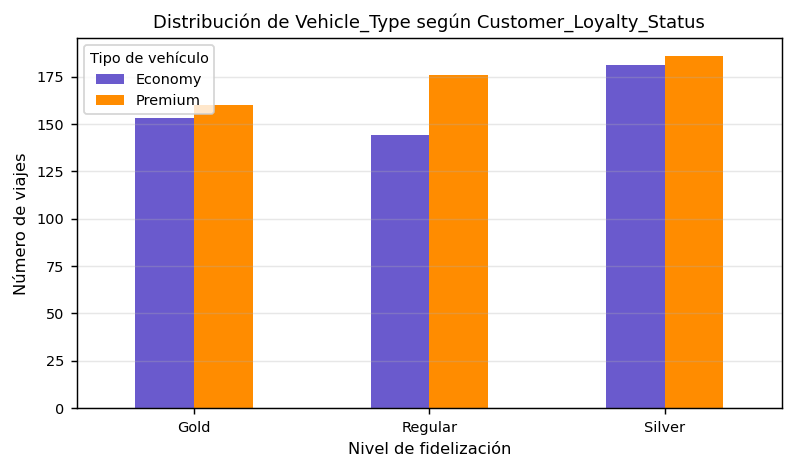

In [82]:
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
tabla_contingencia.plot(kind='bar', ax=ax, color=['slateblue', 'darkorange'])
ax.set_title('Distribución de Vehicle_Type según Customer_Loyalty_Status', fontsize=10)
ax.set_xlabel('Nivel de fidelización', fontsize=9)
ax.set_ylabel('Número de viajes', fontsize=9)
ax.set_xticklabels(tabla_contingencia.index, rotation=0, fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.legend(title='Tipo de vehículo', fontsize=8, title_fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.show()

**Hipótesis:**
H0: Customer_Loyalty_Status y Vehicle_Type son independientes (no existe relación entre el nivel de fidelización y el tipo de vehículo utilizado)
H1: Customer_Loyalty_Status y Vehicle_Type no son independientes (existe una relación entre ambas variables)

**Tabla de contingencia observada:**

| Loyalty Status | Economy | Premium |
|---|---|---|
| Gold | 153 | 160 |
| Regular | 144 | 176 |
| Silver | 181 | 186 |

**Resultado y decisión:**
Se obtuvo un estadístico chi-cuadrado de 1.4916 con 2 grados de libertad y un p-valor de 0.4744. Dado que este p-valor es mayor al nivel de significancia α = 0.05, **no se rechaza H0**. Además, la V de Cramér (0.0386) es muy cercana a cero, lo que indicaría una asociación prácticamente nula incluso si hubiese sido estadísticamente significativa.

**Conclusión:**
No se encontró evidencia estadística suficiente para afirmar que existe una relación de dependencia entre el nivel de fidelización del cliente (`Customer_Loyalty_Status`) y el tipo de vehículo utilizado (`Vehicle_Type`). Las frecuencias observadas en cada combinación de categorías son muy similares a las frecuencias esperadas bajo el supuesto de independencia, lo que sugiere que ambas variables se comportan de manera independiente en este conjunto de datos. Desde la perspectiva del negocio, esto indica que la elección del tipo de vehículo (Economy o Premium) no está determinada por el nivel de fidelización del cliente: los clientes Gold, Silver y Regular utilizan ambos tipos de vehículo en proporciones comparables, por lo que estrategias de marketing o precios diferenciadas por tipo de vehículo no necesitarían segmentarse adicionalmente por nivel de fidelización.

## 2.6 Análisis de Poder Estadístico y Errores Tipo I y II

En esta sección se calcula el poder estadístico de la prueba t aplicada en el paso 2.3 (comparación de `Expected_Ride_Duration` entre clientes Regular y Gold), y se analizan los riesgos de cometer errores Tipo I y Tipo II en el contexto de este análisis.

Cálculo del tamaño del efecto y el poder estadístico

In [83]:
regular = df[df['Customer_Loyalty_Status'] == 'Regular']['Expected_Ride_Duration']
gold = df[df['Customer_Loyalty_Status'] == 'Gold']['Expected_Ride_Duration']

n1, n2 = len(regular), len(gold)
pooled_sd = np.sqrt(((n1-1)*regular.std(ddof=1)**2 + (n2-1)*gold.std(ddof=1)**2) / (n1+n2-2))
cohens_d = abs(regular.mean() - gold.mean()) / pooled_sd

print(f"n1={n1}, n2={n2} | Diferencia de medias={abs(regular.mean()-gold.mean()):.4f} | d de Cohen={cohens_d:.4f}")

n1=320, n2=313 | Diferencia de medias=1.0382 | d de Cohen=0.0209


<div style="page-break-before: always;"></div>

In [84]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
analisis_poder = TTestIndPower()
poder = analisis_poder.power(effect_size=cohens_d, nobs1=n1, ratio=n2/n1, alpha=alpha, alternative='two-sided')
n_necesario = analisis_poder.solve_power(effect_size=cohens_d, power=0.80, alpha=alpha, ratio=1.0, alternative='two-sided')

print(f"Poder estadístico (1-β) = {poder:.4f} ({poder*100:.2f}%)")
print(f"n necesario por grupo para poder=0.80: {n_necesario:.0f}")

Poder estadístico (1-β) = 0.0579 (5.79%)
n necesario por grupo para poder=0.80: 36051


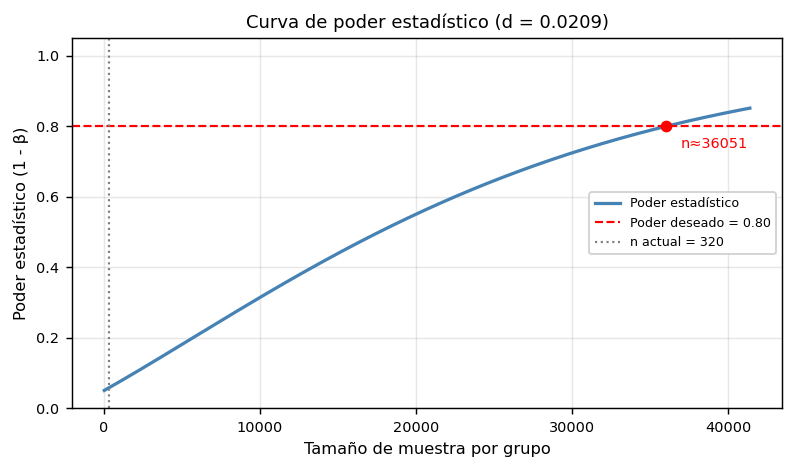

In [86]:
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

# Reducimos el número de puntos calculados (paso más amplio) sin perder la forma de la curva
tamanos_muestra = np.arange(10, max(int(n_necesario*1.15), 2000), 50)
poderes = [analisis_poder.power(effect_size=cohens_d, nobs1=n, ratio=1.0, alpha=alpha, alternative='two-sided') for n in tamanos_muestra]

fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ax.plot(tamanos_muestra, poderes, color='steelblue', linewidth=1.8, label='Poder estadístico')
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=1.2, label='Poder deseado = 0.80')
ax.axvline(x=n1, color='gray', linestyle=':', linewidth=1.2, label=f'n actual = {n1}')
ax.scatter([n_necesario], [0.80], color='red', zorder=5, s=30)
ax.annotate(f'n≈{n_necesario:.0f}', (n_necesario, 0.80), textcoords="offset points", xytext=(8, -12), fontsize=8, color='red')
ax.set_xlabel('Tamaño de muestra por grupo', fontsize=9)
ax.set_ylabel('Poder estadístico (1 - β)', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title(f'Curva de poder estadístico (d = {cohens_d:.4f})', fontsize=10)
ax.legend(loc='center right', fontsize=7, framealpha=0.9)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.3)
plt.show()

### Interpretación de resultados

**Parámetros del análisis:**
Tamaño del efecto estimado (d de Cohen): 0.0209 — según los criterios convencionales de Cohen   (pequeño ≈ 0.2, mediano ≈ 0.5, grande ≈ 0.8), este es un efecto extremadamente pequeño, prácticamente insignificante en términos prácticos.
Tamaño de muestra: n = 320 (Regular) y n = 313 (Gold).
Nivel de significancia: α = 0.05.

**Poder estadístico obtenido: 0.0579 (5.79%)**
El poder estadístico calculado para la prueba t aplicada en el paso 2.3 es de apenas 5.79%, muy por debajo del umbral convencionalmente deseable de 80%. Esto significa que, incluso si existiera una diferencia real de esa magnitud (d=0.0209) entre las medias poblacionales de `Expected_Ride_Duration` para clientes Regular y Gold, esta prueba tendría solo un 5.79% de probabilidad de detectarla
correctamente. Para alcanzar un poder de 0.80 con un efecto de este tamaño, se necesitarían aproximadamente 36,051 observaciones por grupo, una cifra muy superior al tamaño de muestra disponible. Este resultado es coherente con la decisión tomada en el paso 2.3 de no rechazar H0: dado el bajo poder de la prueba, la ausencia de significancia estadística no debe interpretarse como una confirmación de que las medias son iguales, sino que, de existir una diferencia real, esta sería tan pequeña que la prueba no tendría capacidad suficiente para detectarla con el tamaño de muestra actual.

**Análisis de los errores Tipo I y Tipo II y su impacto en decisiones organizacionales:**

**Error Tipo I (falso positivo):** ocurre cuando se rechaza H0 siendo esta verdadera, es decir,   concluir que existe una diferencia entre grupos (por ejemplo, entre Regular y Gold) cuando en   realidad no la hay. La probabilidad de cometer este error es igual a α = 0.05. En un contexto   organizacional, cometer un error Tipo I podría llevar a la empresa a implementar estrategias   diferenciadas e innecesarias por nivel de fidelización (por ejemplo, ajustar tiempos de servicio   o políticas operativas específicas para clientes Gold), generando costos y complejidad operativa sin un beneficio real.

**Error Tipo II (falso negativo):** ocurre cuando no se rechaza H0 siendo esta falsa, es decir, no detectar una diferencia que sí existe en la población. La probabilidad de este error es β, y en este caso β = 1 - poder = 1 - 0.0579 = 0.9421, es decir, un riesgo muy alto (94.21%) de no detectar una diferencia real si esta existiera y fuese del tamaño estimado. En un contexto organizacional, este es el riesgo más relevante en este análisis: la empresa podría descartar erróneamente la existencia de diferencias reales entre segmentos de clientes por fidelización,   perdiendo la oportunidad de diseñar estrategias de servicio diferenciadas que sí agregarían valor si la diferencia real fuera de mayor magnitud.

**Impacto conjunto en la toma de decisiones:** el bajo poder estadístico observado (5.79%) advierte que las conclusiones de "no rechazo de H0" en pruebas con tamaños de efecto pequeños y tamaños de muestra insuficientes deben interpretarse con cautela. No es equivalente decir "no hay evidencia de diferencia" a decir "no hay diferencia": la primera reconoce la limitación de
la prueba, mientras que la segunda sería una afirmación que la evidencia disponible no permite sostener con este nivel de poder. Para decisiones organizacionales de alto impacto, sería recomendable aumentar el tamaño de muestra o enfocar el análisis en variables donde el tamaño del efecto esperado sea mayor, antes de descartar por completo la existencia de diferencias entre   segmentos de clientes.

**Estrategias para mejorar el poder estadístico en futuros análisis:**
Existen dos palancas principales para mejorar el poder de una prueba estadística: (1) reducir el nivel de significancia α disminuye el riesgo de cometer un error Tipo I (falso positivo), aunque esto por sí solo puede aumentar el riesgo de error Tipo II si no se ajusta también el tamaño de
muestra; y (2) aumentar el tamaño de muestra reduce β y, en consecuencia, incrementa el poder,permitiendo detectar efectos reales de menor magnitud con mayor probabilidad. Dado el bajo poder obtenido en este análisis (5.79%), la estrategia más efectiva para este caso particular sería aumentar sustancialmente el tamaño de muestra (como lo confirma el cálculo de n≈36,051 observaciones por grupo necesarias para alcanzar un poder de 0.80), si el objetivo fuera detectar con confianza estadística una diferencia real de esta magnitud entre los grupos de fidelización.